In [3]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer

from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PowerTransformer

In [6]:
customers = pd.read_csv("customer.csv")
customers.head()

,customer_id,name,age,gender,income,education,signup_date,purchased
0,C001,John,25.0,Male,45000.0,Graduate,2023-01-15,1
1,C002,Alice,32.0,Female,55000.0,Postgraduate,2022-05-20,0
2,C003,Bob,29.0,Male,NaN,Graduate,2023-03-10,1
3,C004,Emma,41.0,Female,72000.0,High School,2021-12-05,0
4,C005,David,NaN,Male,65000.0,Graduate,2022-08-17,1


In [7]:
transactions = pd.read_json("customer.json")
transactions.head()

,transaction_id,customer_id,product_id,purchase_amount,last_purchase_date
0,T001,C001,P001,1200,2024-01-10
1,T002,C002,P002,850,2024-02-15
2,T003,C003,P003,1500,2024-03-12
3,T004,C004,P001,650,2024-01-28


In [19]:
import sqlite3

conn = sqlite3.connect("products.db")

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS products(
    product_id TEXT PRIMARY KEY,
    product_name TEXT,
    category TEXT,
    price REAL
)
""")

products = [
    ("P001","Laptop","Electronics",50000),
    ("P002","Mobile","Electronics",25000),
    ("P003","Tablet","Electronics",18000),
    ("P004","Headphone","Accessories",3000),
    ("P005","Smart Watch","Accessories",7000)
]

cursor.executemany(
    "INSERT OR REPLACE INTO products VALUES (?,?,?,?)",
    products
)

conn.commit()

print("products.db created successfully")

conn.close()

products.db created successfully


In [20]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("products.db")

products = pd.read_sql(
    "SELECT * FROM products",
    conn
)

print(products)

conn.close()

  product_id product_name     category    price
0       P001       Laptop  Electronics  50000.0
1       P002       Mobile  Electronics  25000.0
2       P003       Tablet  Electronics  18000.0
3       P004    Headphone  Accessories   3000.0
4       P005  Smart Watch  Accessories   7000.0


In [21]:
import requests

response = requests.get("https://dummyjson.com/users")

api_users = pd.DataFrame(response.json()['users'])

api_users.head()

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


In [22]:
df = customers.merge(
    transactions,
    on="customer_id",
    how="left"
)

df = df.merge(
    products,
    on="product_id",
    how="left"
)

df.head()

,customer_id,name,age,gender,income,education,signup_date,purchased,transaction_id,product_id,purchase_amount,last_purchase_date,product_name,category,price
0,C001,John,25.0,Male,45000.0,Graduate,2023-01-15,1,T001,P001,1200.0,2024-01-10,Laptop,Electronics,50000.0
1,C002,Alice,32.0,Female,55000.0,Postgraduate,2022-05-20,0,T002,P002,850.0,2024-02-15,Mobile,Electronics,25000.0
2,C003,Bob,29.0,Male,NaN,Graduate,2023-03-10,1,T003,P003,1500.0,2024-03-12,Tablet,Electronics,18000.0
3,C004,Emma,41.0,Female,72000.0,High School,2021-12-05,0,T004,P001,650.0,2024-01-28,Laptop,Electronics,50000.0
4,C005,David,NaN,Male,65000.0,Graduate,2022-08-17,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df.info()

df.describe()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         8 non-null      object 
 1   name                8 non-null      object 
 2   age                 7 non-null      float64
 3   gender              8 non-null      object 
 4   income              7 non-null      float64
 5   education           7 non-null      object 
 6   signup_date         8 non-null      object 
 7   purchased           8 non-null      int64  
 8   transaction_id      4 non-null      object 
 9   product_id          4 non-null      object 
 10  purchase_amount     4 non-null      float64
 11  last_purchase_date  4 non-null      object 
 12  product_name        4 non-null      object 
 13  category            4 non-null      object 
 14  price               4 non-null      float64
dtypes: float64(4), int64(1), object(10)
memory usage: 1.1+ KB


,customer_id,name,age,gender,income,education,signup_date,purchased,transaction_id,product_id,purchase_amount,last_purchase_date,product_name,category,price
0,C001,John,25.0,Male,45000.0,Graduate,2023-01-15,1,T001,P001,1200.0,2024-01-10,Laptop,Electronics,50000.0
1,C002,Alice,32.0,Female,55000.0,Postgraduate,2022-05-20,0,T002,P002,850.0,2024-02-15,Mobile,Electronics,25000.0
2,C003,Bob,29.0,Male,NaN,Graduate,2023-03-10,1,T003,P003,1500.0,2024-03-12,Tablet,Electronics,18000.0
3,C004,Emma,41.0,Female,72000.0,High School,2021-12-05,0,T004,P001,650.0,2024-01-28,Laptop,Electronics,50000.0
4,C005,David,NaN,Male,65000.0,Graduate,2022-08-17,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


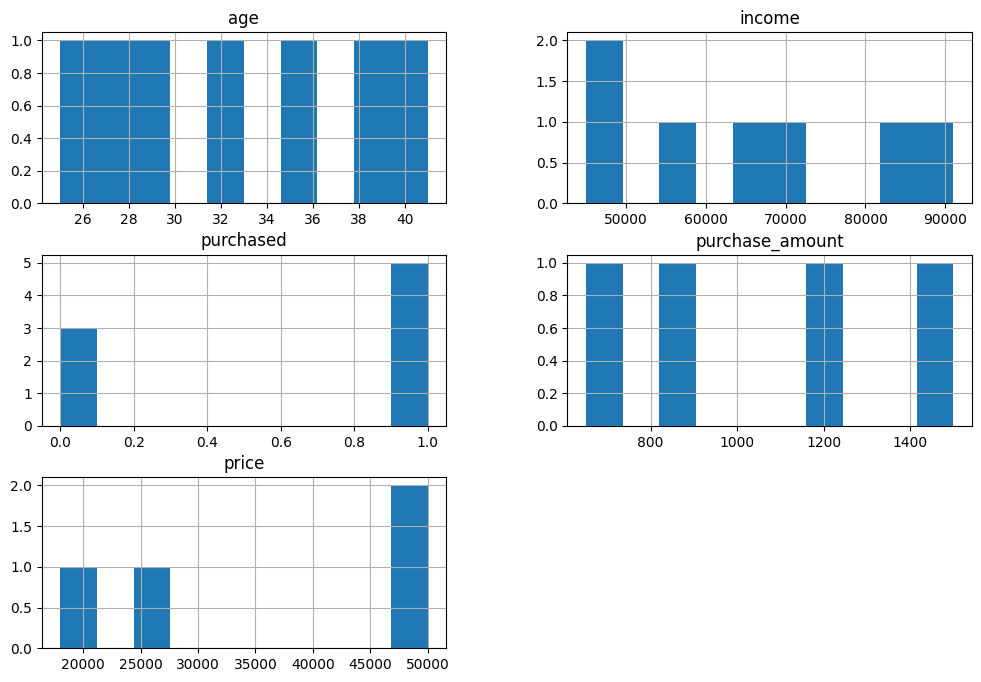

In [24]:
df.hist(figsize=(12,8))
plt.show()

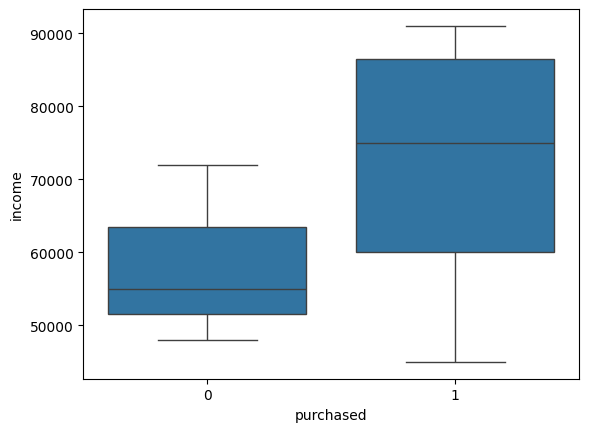

In [25]:
sns.boxplot(
    x='purchased',
    y='income',
    data=df
)
plt.show()

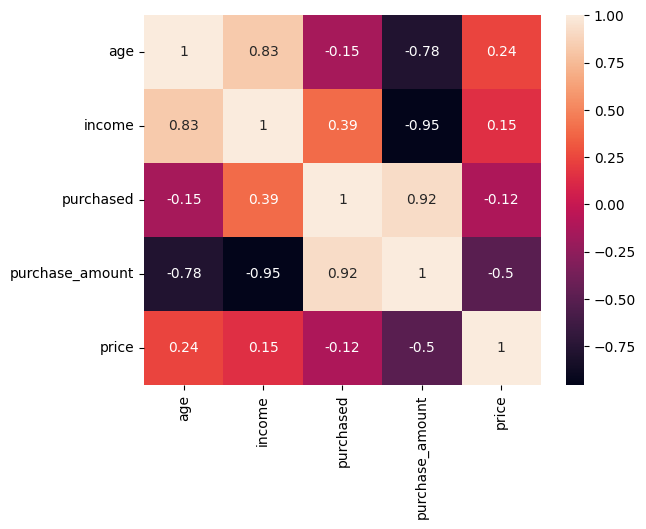

In [26]:
numeric = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True
)
plt.show()

In [29]:
df.isnull().sum()

customer_id           0
name                  0
age                   1
gender                0
income                1
education             1
signup_date           0
purchased             0
transaction_id        4
product_id            4
purchase_amount       4
last_purchase_date    4
product_name          4
category              4
price                 4
dtype: int64

In [31]:
num_cols = df.select_dtypes(include=np.number).columns

si = SimpleImputer(strategy="median")

df[num_cols] = si.fit_transform(df[num_cols])
print(df)

  customer_id    name   age  gender   income     education signup_date  \
0        C001    John  25.0    Male  45000.0      Graduate  2023-01-15   
1        C002   Alice  32.0  Female  55000.0  Postgraduate  2022-05-20   
2        C003     Bob  29.0    Male  65000.0      Graduate  2023-03-10   
3        C004    Emma  41.0  Female  72000.0   High School  2021-12-05   
4        C005   David  32.0    Male  65000.0      Graduate  2022-08-17   
5        C006  Sophia  35.0  Female  85000.0           NaN  2020-09-12   
6        C007   James  28.0    Male  48000.0      Graduate  2023-06-01   
7        C008  Olivia  39.0  Female  91000.0  Postgraduate  2021-11-25   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
0        1.0           T001       P001           1200.0         2024-01-10   
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0         

In [33]:
cat_cols = df.select_dtypes(include="object").columns

si2 = SimpleImputer(strategy="most_frequent")

df[cat_cols] = si2.fit_transform(df[cat_cols])
print(df)

  customer_id    name   age  gender   income     education signup_date  \
0        C001    John  25.0    Male  45000.0      Graduate  2023-01-15   
1        C002   Alice  32.0  Female  55000.0  Postgraduate  2022-05-20   
2        C003     Bob  29.0    Male  65000.0      Graduate  2023-03-10   
3        C004    Emma  41.0  Female  72000.0   High School  2021-12-05   
4        C005   David  32.0    Male  65000.0      Graduate  2022-08-17   
5        C006  Sophia  35.0  Female  85000.0      Graduate  2020-09-12   
6        C007   James  28.0    Male  48000.0      Graduate  2023-06-01   
7        C008  Olivia  39.0  Female  91000.0  Postgraduate  2021-11-25   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
0        1.0           T001       P001           1200.0         2024-01-10   
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0         

In [34]:
df["income_missing"] = customers["income"].isnull().astype(int)
print(df)

  customer_id    name   age  gender   income     education signup_date  \
0        C001    John  25.0    Male  45000.0      Graduate  2023-01-15   
1        C002   Alice  32.0  Female  55000.0  Postgraduate  2022-05-20   
2        C003     Bob  29.0    Male  65000.0      Graduate  2023-03-10   
3        C004    Emma  41.0  Female  72000.0   High School  2021-12-05   
4        C005   David  32.0    Male  65000.0      Graduate  2022-08-17   
5        C006  Sophia  35.0  Female  85000.0      Graduate  2020-09-12   
6        C007   James  28.0    Male  48000.0      Graduate  2023-06-01   
7        C008  Olivia  39.0  Female  91000.0  Postgraduate  2021-11-25   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
0        1.0           T001       P001           1200.0         2024-01-10   
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0         

In [36]:
knn = KNNImputer()

df[num_cols] = knn.fit_transform(df[num_cols])
print(df)

  customer_id    name   age  gender   income     education signup_date  \
0        C001    John  25.0    Male  45000.0      Graduate  2023-01-15   
1        C002   Alice  32.0  Female  55000.0  Postgraduate  2022-05-20   
2        C003     Bob  29.0    Male  65000.0      Graduate  2023-03-10   
3        C004    Emma  41.0  Female  72000.0   High School  2021-12-05   
4        C005   David  32.0    Male  65000.0      Graduate  2022-08-17   
5        C006  Sophia  35.0  Female  85000.0      Graduate  2020-09-12   
6        C007   James  28.0    Male  48000.0      Graduate  2023-06-01   
7        C008  Olivia  39.0  Female  91000.0  Postgraduate  2021-11-25   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
0        1.0           T001       P001           1200.0         2024-01-10   
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0         

In [37]:
mice = IterativeImputer()

df[num_cols] = mice.fit_transform(df[num_cols])
print(df)

  customer_id    name   age  gender   income     education signup_date  \
0        C001    John  25.0    Male  45000.0      Graduate  2023-01-15   
1        C002   Alice  32.0  Female  55000.0  Postgraduate  2022-05-20   
2        C003     Bob  29.0    Male  65000.0      Graduate  2023-03-10   
3        C004    Emma  41.0  Female  72000.0   High School  2021-12-05   
4        C005   David  32.0    Male  65000.0      Graduate  2022-08-17   
5        C006  Sophia  35.0  Female  85000.0      Graduate  2020-09-12   
6        C007   James  28.0    Male  48000.0      Graduate  2023-06-01   
7        C008  Olivia  39.0  Female  91000.0  Postgraduate  2021-11-25   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
0        1.0           T001       P001           1200.0         2024-01-10   
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0         

In [39]:
cca = df.dropna()
print(cca)


  customer_id    name   age  gender   income     education signup_date  \
0        C001    John  25.0    Male  45000.0      Graduate  2023-01-15   
1        C002   Alice  32.0  Female  55000.0  Postgraduate  2022-05-20   
2        C003     Bob  29.0    Male  65000.0      Graduate  2023-03-10   
3        C004    Emma  41.0  Female  72000.0   High School  2021-12-05   
4        C005   David  32.0    Male  65000.0      Graduate  2022-08-17   
5        C006  Sophia  35.0  Female  85000.0      Graduate  2020-09-12   
6        C007   James  28.0    Male  48000.0      Graduate  2023-06-01   
7        C008  Olivia  39.0  Female  91000.0  Postgraduate  2021-11-25   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
0        1.0           T001       P001           1200.0         2024-01-10   
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0         

In [40]:
df["zscore"] = zscore(df["income"])

outliers = df[np.abs(df["zscore"]) > 3]

print(outliers)

Empty DataFrame
Columns: [customer_id, name, age, gender, income, education, signup_date, purchased, transaction_id, product_id, purchase_amount, last_purchase_date, product_name, category, price, income_missing, zscore]
Index: []


In [42]:
Q1 = df["income"].quantile(0.25)

Q3 = df["income"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df_iqr = df[
    (df["income"] >= lower) &
    (df["income"] <= upper)
]
print(df)

  customer_id    name   age  gender   income     education signup_date  \
0        C001    John  25.0    Male  45000.0      Graduate  2023-01-15   
1        C002   Alice  32.0  Female  55000.0  Postgraduate  2022-05-20   
2        C003     Bob  29.0    Male  65000.0      Graduate  2023-03-10   
3        C004    Emma  41.0  Female  72000.0   High School  2021-12-05   
4        C005   David  32.0    Male  65000.0      Graduate  2022-08-17   
5        C006  Sophia  35.0  Female  85000.0      Graduate  2020-09-12   
6        C007   James  28.0    Male  48000.0      Graduate  2023-06-01   
7        C008  Olivia  39.0  Female  91000.0  Postgraduate  2021-11-25   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
0        1.0           T001       P001           1200.0         2024-01-10   
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0         

In [44]:
lower = df["income"].quantile(0.01)

upper = df["income"].quantile(0.99)

df = df[
    (df["income"] >= lower) &
    (df["income"] <= upper)
]
print(df)

  customer_id   name   age  gender   income     education signup_date  \
1        C002  Alice  32.0  Female  55000.0  Postgraduate  2022-05-20   
2        C003    Bob  29.0    Male  65000.0      Graduate  2023-03-10   
3        C004   Emma  41.0  Female  72000.0   High School  2021-12-05   
4        C005  David  32.0    Male  65000.0      Graduate  2022-08-17   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0           T004       P001            650.0         2024-01-28   
4        1.0           T001       P001           1025.0         2024-01-10   

  product_name     category    price  income_missing    zscore  
1       Mobile  Electronics  25000.0               0 -0.695815  
2       Tablet  Electronics  18000.0               1 -0.048545  
3       Laptop  Electronics  50000.0            

In [45]:
df["signup_date"] = pd.to_datetime(df["signup_date"])

df["last_purchase_date"] = pd.to_datetime(
    df["last_purchase_date"]
)
print(df)

  customer_id   name   age  gender   income     education signup_date  \
1        C002  Alice  32.0  Female  55000.0  Postgraduate  2022-05-20   
2        C003    Bob  29.0    Male  65000.0      Graduate  2023-03-10   
3        C004   Emma  41.0  Female  72000.0   High School  2021-12-05   
4        C005  David  32.0    Male  65000.0      Graduate  2022-08-17   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0           T004       P001            650.0         2024-01-28   
4        1.0           T001       P001           1025.0         2024-01-10   

  product_name     category    price  income_missing    zscore  
1       Mobile  Electronics  25000.0               0 -0.695815  
2       Tablet  Electronics  18000.0               1 -0.048545  
3       Laptop  Electronics  50000.0            

In [47]:
df["days_since_last_purchase"] = (
    pd.Timestamp.today() -
    df["last_purchase_date"]
).dt.days
print(df)

  customer_id   name   age  gender   income     education signup_date  \
1        C002  Alice  32.0  Female  55000.0  Postgraduate  2022-05-20   
2        C003    Bob  29.0    Male  65000.0      Graduate  2023-03-10   
3        C004   Emma  41.0  Female  72000.0   High School  2021-12-05   
4        C005  David  32.0    Male  65000.0      Graduate  2022-08-17   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0           T004       P001            650.0         2024-01-28   
4        1.0           T001       P001           1025.0         2024-01-10   

  product_name     category    price  income_missing    zscore  \
1       Mobile  Electronics  25000.0               0 -0.695815   
2       Tablet  Electronics  18000.0               1 -0.048545   
3       Laptop  Electronics  50000.0         

In [48]:
df["customer_num"] = df["customer_id"].str.replace(
    "C",
    ""
).astype(int)
print(df)

  customer_id   name   age  gender   income     education signup_date  \
1        C002  Alice  32.0  Female  55000.0  Postgraduate  2022-05-20   
2        C003    Bob  29.0    Male  65000.0      Graduate  2023-03-10   
3        C004   Emma  41.0  Female  72000.0   High School  2021-12-05   
4        C005  David  32.0    Male  65000.0      Graduate  2022-08-17   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0           T004       P001            650.0         2024-01-28   
4        1.0           T001       P001           1025.0         2024-01-10   

  product_name     category    price  income_missing    zscore  \
1       Mobile  Electronics  25000.0               0 -0.695815   
2       Tablet  Electronics  18000.0               1 -0.048545   
3       Laptop  Electronics  50000.0         

In [50]:
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
print(df)

  customer_id   name   age  gender   income     education signup_date  \
1        C002  Alice  32.0       0  55000.0  Postgraduate  2022-05-20   
2        C003    Bob  29.0       1  65000.0      Graduate  2023-03-10   
3        C004   Emma  41.0       0  72000.0   High School  2021-12-05   
4        C005  David  32.0       1  65000.0      Graduate  2022-08-17   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0           T004       P001            650.0         2024-01-28   
4        1.0           T001       P001           1025.0         2024-01-10   

  product_name     category    price  income_missing    zscore  \
1       Mobile  Electronics  25000.0               0 -0.695815   
2       Tablet  Electronics  18000.0               1 -0.048545   
3       Laptop  Electronics  50000.0         

In [74]:
from sklearn.preprocessing import OrdinalEncoder

customers["education"] = customers["education"].fillna("High School")

oe = OrdinalEncoder()

customers[["education"]] = oe.fit_transform(
    customers[["education"]]
)

print(customers[["education"]].head())

   education
0        1.0
1        2.0
2        1.0
3        0.0
4        1.0


In [55]:
df = pd.get_dummies(
    df,
    columns=["category"],
    drop_first=True
)
print(df)

  customer_id   name   age  gender   income  education signup_date  purchased  \
1        C002  Alice  32.0       0  55000.0        2.0  2022-05-20        0.0   
2        C003    Bob  29.0       1  65000.0        1.0  2023-03-10        1.0   
3        C004   Emma  41.0       0  72000.0        0.0  2021-12-05        0.0   
4        C005  David  32.0       1  65000.0        1.0  2022-08-17        1.0   

  transaction_id product_id  purchase_amount last_purchase_date product_name  \
1           T002       P002            850.0         2024-02-15       Mobile   
2           T003       P003           1500.0         2024-03-12       Tablet   
3           T004       P001            650.0         2024-01-28       Laptop   
4           T001       P001           1025.0         2024-01-10       Laptop   

     price  income_missing    zscore  days_since_last_purchase  customer_num  
1  25000.0               0 -0.695815                       855             2  
2  18000.0               1 -0.04854

In [56]:
df["income_group"] = pd.qcut(
    df["income"],
    q=4,
    labels=False
)
print(df)

  customer_id   name   age  gender   income  education signup_date  purchased  \
1        C002  Alice  32.0       0  55000.0        2.0  2022-05-20        0.0   
2        C003    Bob  29.0       1  65000.0        1.0  2023-03-10        1.0   
3        C004   Emma  41.0       0  72000.0        0.0  2021-12-05        0.0   
4        C005  David  32.0       1  65000.0        1.0  2022-08-17        1.0   

  transaction_id product_id  purchase_amount last_purchase_date product_name  \
1           T002       P002            850.0         2024-02-15       Mobile   
2           T003       P003           1500.0         2024-03-12       Tablet   
3           T004       P001            650.0         2024-01-28       Laptop   
4           T001       P001           1025.0         2024-01-10       Laptop   

     price  income_missing    zscore  days_since_last_purchase  customer_num  \
1  25000.0               0 -0.695815                       855             2   
2  18000.0               1 -0.048

In [57]:
sc = StandardScaler()

df[["income"]] = sc.fit_transform(
    df[["income"]]
)
print(df)

  customer_id   name   age  gender    income  education signup_date  \
1        C002  Alice  32.0       0 -1.527153        2.0  2022-05-20   
2        C003    Bob  29.0       1  0.123823        1.0  2023-03-10   
3        C004   Emma  41.0       0  1.279507        0.0  2021-12-05   
4        C005  David  32.0       1  0.123823        1.0  2022-08-17   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
1        0.0           T002       P002            850.0         2024-02-15   
2        1.0           T003       P003           1500.0         2024-03-12   
3        0.0           T004       P001            650.0         2024-01-28   
4        1.0           T001       P001           1025.0         2024-01-10   

  product_name    price  income_missing    zscore  days_since_last_purchase  \
1       Mobile  25000.0               0 -0.695815                       855   
2       Tablet  18000.0               1 -0.048545                       829   
3       Laptop  

In [58]:
mm = MinMaxScaler()

df[["purchase_amount"]] = mm.fit_transform(
    df[["purchase_amount"]]
)
print(df)

  customer_id   name   age  gender    income  education signup_date  \
1        C002  Alice  32.0       0 -1.527153        2.0  2022-05-20   
2        C003    Bob  29.0       1  0.123823        1.0  2023-03-10   
3        C004   Emma  41.0       0  1.279507        0.0  2021-12-05   
4        C005  David  32.0       1  0.123823        1.0  2022-08-17   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
1        0.0           T002       P002         0.235294         2024-02-15   
2        1.0           T003       P003         1.000000         2024-03-12   
3        0.0           T004       P001         0.000000         2024-01-28   
4        1.0           T001       P001         0.441176         2024-01-10   

  product_name    price  income_missing    zscore  days_since_last_purchase  \
1       Mobile  25000.0               0 -0.695815                       855   
2       Tablet  18000.0               1 -0.048545                       829   
3       Laptop  

In [59]:
ma = MaxAbsScaler()

df[["price"]] = ma.fit_transform(
    df[["price"]]
)
print(df)

  customer_id   name   age  gender    income  education signup_date  \
1        C002  Alice  32.0       0 -1.527153        2.0  2022-05-20   
2        C003    Bob  29.0       1  0.123823        1.0  2023-03-10   
3        C004   Emma  41.0       0  1.279507        0.0  2021-12-05   
4        C005  David  32.0       1  0.123823        1.0  2022-08-17   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
1        0.0           T002       P002         0.235294         2024-02-15   
2        1.0           T003       P003         1.000000         2024-03-12   
3        0.0           T004       P001         0.000000         2024-01-28   
4        1.0           T001       P001         0.441176         2024-01-10   

  product_name  price  income_missing    zscore  days_since_last_purchase  \
1       Mobile   0.50               0 -0.695815                       855   
2       Tablet   0.36               1 -0.048545                       829   
3       Laptop   1.00 

In [60]:
rb = RobustScaler()

df[["age"]] = rb.fit_transform(
    df[["age"]]
)
print(df)

  customer_id   name  age  gender    income  education signup_date  purchased  \
1        C002  Alice  0.0       0 -1.527153        2.0  2022-05-20        0.0   
2        C003    Bob -1.0       1  0.123823        1.0  2023-03-10        1.0   
3        C004   Emma  3.0       0  1.279507        0.0  2021-12-05        0.0   
4        C005  David  0.0       1  0.123823        1.0  2022-08-17        1.0   

  transaction_id product_id  purchase_amount last_purchase_date product_name  \
1           T002       P002         0.235294         2024-02-15       Mobile   
2           T003       P003         1.000000         2024-03-12       Tablet   
3           T004       P001         0.000000         2024-01-28       Laptop   
4           T001       P001         0.441176         2024-01-10       Laptop   

   price  income_missing    zscore  days_since_last_purchase  customer_num  \
1   0.50               0 -0.695815                       855             2   
2   0.36               1 -0.048545   

In [61]:
norm_cols = ["age","income","price"]

norm = Normalizer()

df[norm_cols] = norm.fit_transform(
    df[norm_cols]
)
print(df)

  customer_id   name       age  gender    income  education signup_date  \
1        C002  Alice  0.000000       0 -0.950360        2.0  2022-05-20   
2        C003    Bob -0.934566       1  0.115721        1.0  2023-03-10   
3        C004   Emma  0.879424       0  0.375076        0.0  2021-12-05   
4        C005  David  0.000000       1  0.162893        1.0  2022-08-17   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
1        0.0           T002       P002         0.235294         2024-02-15   
2        1.0           T003       P003         1.000000         2024-03-12   
3        0.0           T004       P001         0.000000         2024-01-28   
4        1.0           T001       P001         0.441176         2024-01-10   

  product_name     price  income_missing    zscore  days_since_last_purchase  \
1       Mobile  0.311154               0 -0.695815                       855   
2       Tablet  0.336444               1 -0.048545                       

In [62]:
df["purchase_per_day"] = (
    df["purchase_amount"] /
    (df["days_since_last_purchase"] + 1)
)
print(df)

  customer_id   name       age  gender    income  education signup_date  \
1        C002  Alice  0.000000       0 -0.950360        2.0  2022-05-20   
2        C003    Bob -0.934566       1  0.115721        1.0  2023-03-10   
3        C004   Emma  0.879424       0  0.375076        0.0  2021-12-05   
4        C005  David  0.000000       1  0.162893        1.0  2022-08-17   

   purchased transaction_id product_id  purchase_amount last_purchase_date  \
1        0.0           T002       P002         0.235294         2024-02-15   
2        1.0           T003       P003         1.000000         2024-03-12   
3        0.0           T004       P001         0.000000         2024-01-28   
4        1.0           T001       P001         0.441176         2024-01-10   

  product_name     price  income_missing    zscore  days_since_last_purchase  \
1       Mobile  0.311154               0 -0.695815                       855   
2       Tablet  0.336444               1 -0.048545                       

In [63]:
log = FunctionTransformer(np.log1p)

df["purchase_amount_log"] = log.fit_transform(
    df[["purchase_amount"]]
)
print(df)

  customer_id   name       age  gender    income  education signup_date  \
1        C002  Alice  0.000000       0 -0.950360        2.0  2022-05-20   
2        C003    Bob -0.934566       1  0.115721        1.0  2023-03-10   
3        C004   Emma  0.879424       0  0.375076        0.0  2021-12-05   
4        C005  David  0.000000       1  0.162893        1.0  2022-08-17   

   purchased transaction_id product_id  ...  last_purchase_date product_name  \
1        0.0           T002       P002  ...          2024-02-15       Mobile   
2        1.0           T003       P003  ...          2024-03-12       Tablet   
3        0.0           T004       P001  ...          2024-01-28       Laptop   
4        1.0           T001       P001  ...          2024-01-10       Laptop   

      price  income_missing    zscore  days_since_last_purchase  customer_num  \
1  0.311154               0 -0.695815                       855             2   
2  0.336444               1 -0.048545                       8

In [75]:
sqrt = FunctionTransformer(np.sqrt)

df["price_sqrt"] = sqrt.fit_transform(
    df[["price"]]
)
print(df)

  customer_id   name       age  gender    income education signup_date  \
1        C002  Alice  0.000000       0 -0.950360       2.0  2022-05-20   
2        C003    Bob -0.934566       1  0.115721       1.0  2023-03-10   
3        C004   Emma  0.879424       0  0.375076       0.0  2021-12-05   
4        C005  David  0.000000       1  0.162893       1.0  2022-08-17   

   purchased transaction_id product_id  ...  product_name     price  \
1        0.0           T002       P002  ...        Mobile  0.311154   
2        1.0           T003       P003  ...        Tablet  0.336444   
3        0.0           T004       P001  ...        Laptop  0.293141   
4        1.0           T001       P001  ...        Laptop  0.986644   

  income_missing    zscore  days_since_last_purchase  customer_num  \
1              0 -0.695815                       855             2   
2              1 -0.048545                       829             3   
3              0  0.404543                       873           

In [76]:
rec = FunctionTransformer(
    lambda x: 1/(x+1)
)

df["income_reciprocal"] = rec.fit_transform(
    df[["income"]]
)
print(df)

  customer_id   name       age  gender    income education signup_date  \
1        C002  Alice  0.000000       0 -0.950360       2.0  2022-05-20   
2        C003    Bob -0.934566       1  0.115721       1.0  2023-03-10   
3        C004   Emma  0.879424       0  0.375076       0.0  2021-12-05   
4        C005  David  0.000000       1  0.162893       1.0  2022-08-17   

   purchased transaction_id product_id  ...     price income_missing  \
1        0.0           T002       P002  ...  0.311154              0   
2        1.0           T003       P003  ...  0.336444              1   
3        0.0           T004       P001  ...  0.293141              0   
4        1.0           T001       P001  ...  0.986644              0   

     zscore  days_since_last_purchase  customer_num  income_group  \
1 -0.695815                       855             2             0   
2 -0.048545                       829             3             1   
3  0.404543                       873             4          

In [77]:
pt = PowerTransformer(
    method="yeo-johnson"
)

df["income_power"] = pt.fit_transform(
    df[["income"]]
)
print(df)

  customer_id   name       age  gender    income education signup_date  \
1        C002  Alice  0.000000       0 -0.950360       2.0  2022-05-20   
2        C003    Bob -0.934566       1  0.115721       1.0  2023-03-10   
3        C004   Emma  0.879424       0  0.375076       0.0  2021-12-05   
4        C005  David  0.000000       1  0.162893       1.0  2022-08-17   

   purchased transaction_id product_id  ...  income_missing    zscore  \
1        0.0           T002       P002  ...               0 -0.695815   
2        1.0           T003       P003  ...               1 -0.048545   
3        0.0           T004       P001  ...               0  0.404543   
4        1.0           T001       P001  ...               0 -0.048545   

  days_since_last_purchase  customer_num  income_group  purchase_per_day  \
1                      855             2             0          0.000275   
2                      829             3             1          0.001205   
3                      873         

In [78]:
df["frequent_buyer"] = np.where(
    df["purchase_amount"] > 0.5,
    1,
    0
)
print(df)

  customer_id   name       age  gender    income education signup_date  \
1        C002  Alice  0.000000       0 -0.950360       2.0  2022-05-20   
2        C003    Bob -0.934566       1  0.115721       1.0  2023-03-10   
3        C004   Emma  0.879424       0  0.375076       0.0  2021-12-05   
4        C005  David  0.000000       1  0.162893       1.0  2022-08-17   

   purchased transaction_id product_id  ...    zscore  \
1        0.0           T002       P002  ... -0.695815   
2        1.0           T003       P003  ... -0.048545   
3        0.0           T004       P001  ...  0.404543   
4        1.0           T001       P001  ... -0.048545   

  days_since_last_purchase customer_num  income_group  purchase_per_day  \
1                      855            2             0          0.000275   
2                      829            3             1          0.001205   
3                      873            4             3          0.000000   
4                      891            5    

In [79]:
df.head()

,customer_id,name,age,gender,income,education,signup_date,purchased,transaction_id,product_id,...,zscore,days_since_last_purchase,customer_num,income_group,purchase_per_day,purchase_amount_log,price_sqrt,income_reciprocal,income_power,frequent_buyer
1,C002,Alice,0.000000,0,-0.950360,2.0,2022-05-20,0.0,T002,P002,...,-0.695815,855,2,0,0.000275,0.211309,0.557812,20.144855,-1.517349,0
2,C003,Bob,-0.934566,1,0.115721,1.0,2023-03-10,1.0,T003,P003,...,-0.048545,829,3,1,0.001205,0.693147,0.580038,0.896281,0.024433,1
3,C004,Emma,0.879424,0,0.375076,0.0,2021-12-05,0.0,T004,P001,...,0.404543,873,4,3,0.000000,0.000000,0.541425,0.727232,1.286206,0
4,C005,David,0.000000,1,0.162893,1.0,2022-08-17,1.0,T001,P001,...,-0.048545,891,5,1,0.000495,0.365460,0.993299,0.859925,0.206710,0


In [80]:
df.to_csv(
    "processed_customer_data.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully
